<a href="https://colab.research.google.com/github/sarunsmenon/tf_kaggle/blob/main/100_Basic_Chart_Identifier_Model_PyT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install Missing Libs

In [1]:
! pip install --upgrade torchvision

# Load Libraries

In [2]:
import torch
import torchvision
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder

import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim

from torch.utils.data import Subset, Dataset
from sklearn.model_selection import train_test_split
from collections import Counter
from torch.utils.data import DataLoader

from google.colab import drive
from google.colab import data_table
data_table.enable_dataframe_formatter()

In [58]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Define Variables

In [5]:
folder_path = 'drive/MyDrive/Kaggle/benetech-making-graphs-accessible/train/images_sample'
model_path = 'drive/MyDrive/Kaggle/benetech-making-graphs-accessible/model/'

In [6]:
batch_size = 32
img_height = 120
img_width = 300
seed=2011
sample_size = 5000
image_size = (img_height, img_width)
total_epochs = 25

In [7]:
valid_split = 0.3 # keeps 70% of data for training

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("We're using =>", device)

We're using => cuda


# Define Training and Validation dataset

In [16]:
class SubSetTransformer(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
      x, y = self.subset[index]
      #print(f"index is {index} and x is {x} and y is {y}")
      if self.transform:
          x = self.transform(x)
          #print(f"transformed x is {x}")
      return x, y

    def __len__(self):
        return len(self.subset)


In [17]:
train_transformer = v2.Compose([
    v2.ToImage(),
    v2.Resize(image_size,antialias=True),
    v2.RandomHorizontalFlip(0.2),
    v2.RandomVerticalFlip(0.1),
    v2.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    v2.RandomInvert(0.2),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])


non_train_transformer = v2.Compose([
    v2.ToImage(),
    v2.Resize(image_size,antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

In [18]:
all_data = ImageFolder(root=folder_path)

In [19]:
class_names = all_data.class_to_idx
print(class_names)

class_map = {v:k for k,v in class_names.items()}
print(class_map)
len(class_map)

{'bar_chart': 0, 'dot_chart': 1, 'line_chart': 2, 'scatter_chart': 3}
{0: 'bar_chart', 1: 'dot_chart', 2: 'line_chart', 3: 'scatter_chart'}


4

In [20]:
train_indices, holdout_indices, train_targets, holdout_targets = train_test_split(
    range(len(all_data)),
    all_data.targets,
    stratify=all_data.targets,
    test_size=valid_split,
    random_state=1
)

train_dataset = Subset(all_data, train_indices)
holdout_dataset = Subset(all_data, holdout_indices)

train_indices, val_indices, _, _ = train_test_split(
    train_indices,
    train_targets,
    stratify=train_targets,
    test_size=0.2,
    random_state=1
)

# this way of sampling does not work because the transformations are differnt for each train, valid and holdout dataset

# train_sampler = torch.utils.data.SubsetRandomSampler(train_indices)
# valid_sampler = torch.utils.data.SubsetRandomSampler(val_indices)
# holdout_sampler = torch.utils.data.SubsetRandomSampler(holdout_indices)

# train_loader = torch.utils.data.DataLoader(all_data, batch_size=batch_size, sampler=train_sampler)
# valid_loader = torch.utils.data.DataLoader(all_data, batch_size=batch_size, sampler=valid_sampler)
# holdout_loader = torch.utils.data.DataLoader(all_data, batch_size=batch_size, sampler=holdout_sampler)


train_dataset = Subset(all_data, train_indices)
val_dataset =  Subset(all_data, val_indices)


In [21]:
train_ds = SubSetTransformer(subset=train_dataset, transform=train_transformer)
val_ds = SubSetTransformer(subset=val_dataset, transform=non_train_transformer)
holdout_ds = SubSetTransformer(subset=holdout_dataset, transform=non_train_transformer)

In [22]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=True)
holdout_loader = DataLoader(holdout_ds, batch_size=batch_size, shuffle=True)


In [23]:
print(len(train_loader))
print(len(valid_loader))
print(len(holdout_loader))

106
27
57


# Visualise Images

Text(0.5, 1.0, 'bar_chart')

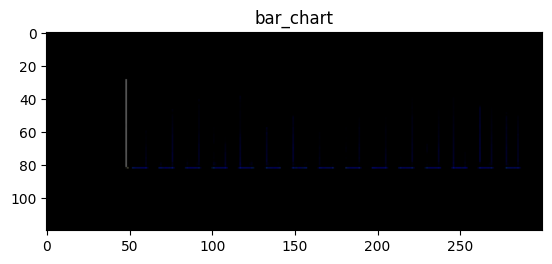

In [ ]:
import matplotlib.pyplot as plt
single_batch = next(iter(train_loader))
# Selecting the first image tensor from the batch.
img_index = 11
single_image = single_batch[0][img_index]
single_image.shape
plt.imshow(single_image.permute(1, 2, 0))
plt.title(class_map[single_batch[1].numpy()[img_index]])

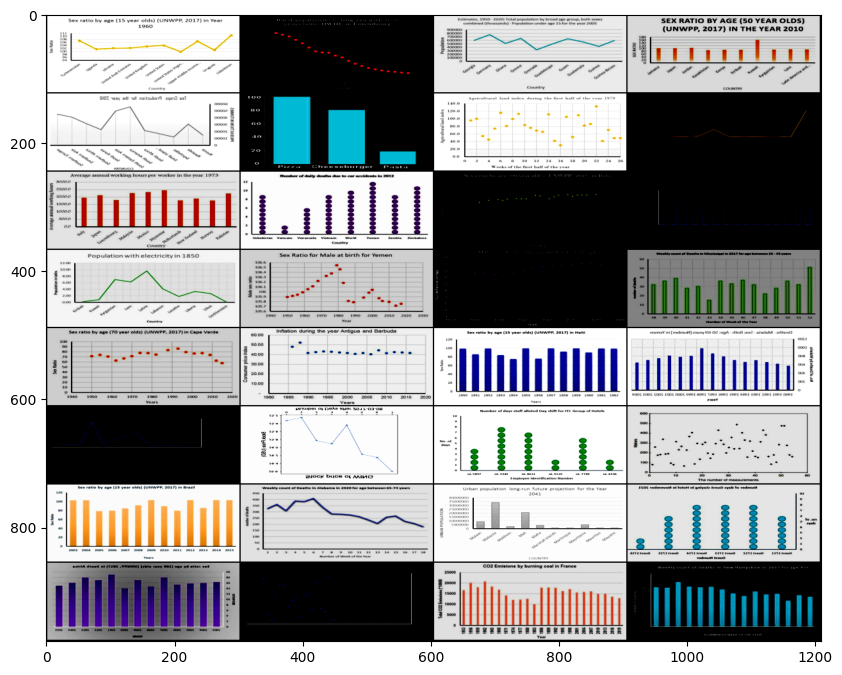

In [ ]:
single_batch_grid = torchvision.utils.make_grid(single_batch[0], nrow=4)
plt.figure(figsize = (10,10))
plt.imshow(single_batch_grid.permute(1, 2, 0))

# Build Model

In [ ]:
class CLF(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear( in_features = 3 * img_height * img_width, out_features= 2048)
    self.fc2 = nn.Linear( in_features = 2048, out_features = 1024 )
    self.fc3 = nn.Linear( in_features = 1024, out_features = 64 )
    self.fc4 = nn.Linear( in_features = 64, out_features = len(class_map))

  def forward(self, x):
    x = x.view(-1, 3 * img_height * img_width)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    x = self.fc4(x)
    return x

In [ ]:
class CLF_CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.cnn_feat = nn.Sequential(
        nn.Conv2d(3,64, kernel_size=5, padding=2),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride = 2),

        nn.Conv2d(64,512, kernel_size=5, padding=2),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride = 2),

        nn.Conv2d(512,1024, kernel_size=5, padding=2),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride = 2),

        nn.Conv2d(1024,256, kernel_size=5, padding=2),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride = 2),

    )

    self.avgpool = nn.AdaptiveAvgPool2d((6,6))

    self.nn = nn.Sequential(
        nn.Dropout(),
        nn.Linear(256 * 6 * 6, 4096),
        nn.ReLU(),
        nn.Dropout(),
        nn.Linear(4096, 512),
        nn.ReLU(),
        nn.Linear(512,len(class_map) )
    )

  def forward(self, x):
    x = self.cnn_feat(x)
    x = self.avgpool(x)
    x = torch.flatten(x,1)
    x = self.nn(x)
    return x

In [13]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 83.5MB/s]


In [14]:
class CLF_CNN_ResNet(nn.Module):
  def __init__(self):
    super().__init__()

    self.cnn_feat = torchvision.models.resnet18(weights='IMAGENET1K_V1')
    for param in self.cnn_feat.parameters():
        param.requires_grad = False

    self.nn = nn.Sequential(
        nn.Dropout(),
        nn.Linear(self.cnn_feat.fc.out_features, 512),
        nn.ReLU(),
        nn.Dropout(),
        nn.Linear(512,len(class_map) )
    )

  def forward(self, x):
    x = self.cnn_feat(x)
    x = torch.flatten(x,1)
    x = self.nn(x)
    return x

In [24]:
clf = CLF_CNN_ResNet()
clf.to(device)
print(clf)

CLF_CNN_ResNet(
  (cnn_feat): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, t

In [25]:
optimizer = optim.Adam(clf.parameters(), lr = 0.01)
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


In [26]:
criterion = nn.CrossEntropyLoss()
print(criterion)

CrossEntropyLoss()


# Train

In [34]:
def train(model, optimizer, loss_fn, train_loader, valid_loader, epochs = 15, device= 'cpu'):

  for epoch in range(epochs):
    train_loss = 0.0
    val_loss = 0.0
    model.train()

    for i, batch in enumerate(train_loader):
      if i %25 == 0 :
        print(f"starting {i} out of {len(train_loader)} run of {epoch} ")

      optimizer.zero_grad();

      x, y = batch
      x = x.to(device)
      y = y.to(device)

      y_pred = model(x)

      loss = loss_fn(y_pred, y)

      loss.backward()
      optimizer.step()

      train_loss = train_loss + loss.data.item()

    train_loss = train_loss / len(train_loader)

    model.eval()
    num_correct = 0
    num_examples = 0

    for batch in valid_loader:
      x_val, y_val = batch
      x_val = x_val.to(device)
      y_val = y_val.to(device)

      output = model(x_val) # this will be an array of scores for all classes
      val_loss = val_loss + loss.data.item()

      y_val_pred = torch.max(F.softmax(output, -1), dim=1)[1]

      correct = torch.eq(y_val_pred, y_val).view(-1)
      num_correct = num_correct + torch.sum(correct).item()
      num_examples = num_examples + correct.shape[0]

    val_loss = val_loss / len(valid_loader)

    print(" Epoch {} , Training Loss : {:0.2f}, Valid Loss: {:.2f}, accuracy : {:0.2f} ".format(epoch, train_loss, val_loss, num_correct/num_examples))


In [35]:
train(model=clf, optimizer=optimizer, valid_loader=valid_loader, train_loader=train_loader, loss_fn=criterion, device = device)

starting 0 out of 106 run of 0 
starting 25 out of 106 run of 0 
starting 50 out of 106 run of 0 
starting 75 out of 106 run of 0 
starting 100 out of 106 run of 0 
 Epoch 0 , Training Loss : 1.93, Valid Loss: 0.26, accuracy : 0.98 
starting 0 out of 106 run of 1 
starting 25 out of 106 run of 1 
starting 50 out of 106 run of 1 
starting 75 out of 106 run of 1 
starting 100 out of 106 run of 1 
 Epoch 1 , Training Loss : 2.74, Valid Loss: 1.52, accuracy : 0.98 
starting 0 out of 106 run of 2 
starting 25 out of 106 run of 2 
starting 50 out of 106 run of 2 
starting 75 out of 106 run of 2 
starting 100 out of 106 run of 2 
 Epoch 2 , Training Loss : 2.79, Valid Loss: 3.55, accuracy : 0.98 
starting 0 out of 106 run of 3 
starting 25 out of 106 run of 3 
starting 50 out of 106 run of 3 
starting 75 out of 106 run of 3 
starting 100 out of 106 run of 3 
 Epoch 3 , Training Loss : 3.81, Valid Loss: 1.98, accuracy : 0.98 
starting 0 out of 106 run of 4 
starting 25 out of 106 run of 4 
sta

# Model Save

In [36]:
file = open(model_path+'Basic_Chart_Identifier_Model_PyT_0.3.pkl', 'wb')
pickle.dump(clf, file)
file.close()

# Inference

In [27]:
with open(model_path+'Basic_Chart_Identifier_Model_PyT_0.3.pkl', 'rb') as f:
  model = pickle.loads(f.read())

In [28]:
y_pred_lst = []
y_true_lst = []
model.eval()

for i,batch in enumerate(holdout_loader):
  print(f"Processing batch :: {i}")
  x_h, y_h = batch
  x_h = x_h.to(device)
  output = model(x_h)
  #y_h_pred = F.softmax(output, -1)
  y_h_pred = torch.max(F.softmax(output, -1), dim=1)[1]

  y_true_lst.append(y_h)
  y_pred_lst.append(y_h_pred)


Processing batch :: 0
Processing batch :: 1
Processing batch :: 2
Processing batch :: 3
Processing batch :: 4
Processing batch :: 5
Processing batch :: 6
Processing batch :: 7
Processing batch :: 8
Processing batch :: 9
Processing batch :: 10
Processing batch :: 11
Processing batch :: 12
Processing batch :: 13
Processing batch :: 14
Processing batch :: 15
Processing batch :: 16
Processing batch :: 17
Processing batch :: 18
Processing batch :: 19
Processing batch :: 20
Processing batch :: 21
Processing batch :: 22
Processing batch :: 23
Processing batch :: 24
Processing batch :: 25
Processing batch :: 26
Processing batch :: 27
Processing batch :: 28
Processing batch :: 29
Processing batch :: 30
Processing batch :: 31
Processing batch :: 32
Processing batch :: 33
Processing batch :: 34
Processing batch :: 35
Processing batch :: 36
Processing batch :: 37
Processing batch :: 38
Processing batch :: 39
Processing batch :: 40
Processing batch :: 41
Processing batch :: 42
Processing batch :: 4

In [29]:
y_pred_arr = torch.cat(y_pred_lst).cpu().numpy()
y_true_arr = torch.cat(y_true_lst).cpu().numpy()

In [35]:
y_pred_name = [class_map.get(i) for i in y_pred_arr]
y_true_name = [class_map.get(i) for i in y_true_arr]

In [37]:
y_df = pd.DataFrame({'y_pred_key' : y_pred_arr,'y_true_key' :y_true_arr, 'y_pred_val' :y_pred_name, 'y_true_val' :y_true_name })
y_df

,y_pred_key,y_true_key,y_pred_val,y_true_val
0,2,2,line_chart,line_chart
1,3,3,scatter_chart,scatter_chart
2,2,2,line_chart,line_chart
3,2,2,line_chart,line_chart
4,2,2,line_chart,line_chart
...,...,...,...,...
1813,2,2,line_chart,line_chart
1814,3,3,scatter_chart,scatter_chart
1815,2,2,line_chart,line_chart
1816,2,2,line_chart,line_chart


# Evaluation

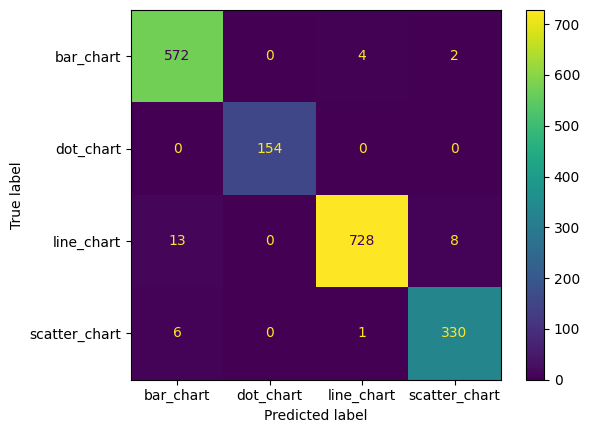

In [39]:
ConfusionMatrixDisplay.from_predictions(
    y_df['y_true_val'], y_df['y_pred_val'], labels=list(class_names.keys())
)

In [43]:
print(classification_report(y_df['y_true_val'], y_df['y_pred_val'], target_names=list(class_names.keys())))

               precision    recall  f1-score   support

    bar_chart       0.97      0.99      0.98       578
    dot_chart       1.00      1.00      1.00       154
   line_chart       0.99      0.97      0.98       749
scatter_chart       0.97      0.98      0.97       337

     accuracy                           0.98      1818
    macro avg       0.98      0.99      0.98      1818
 weighted avg       0.98      0.98      0.98      1818



# Inference on Batch Loader

In [104]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(holdout_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                pred_label = class_map[preds[j].cpu().item()]
                ax.set_title(f'predicted: {pred_label}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [107]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  #

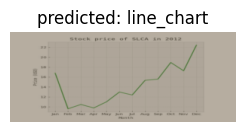

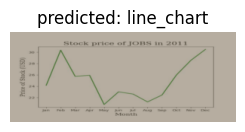

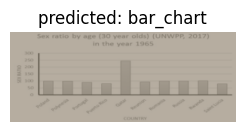

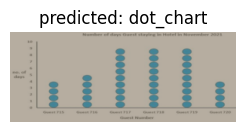

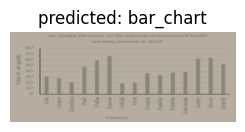

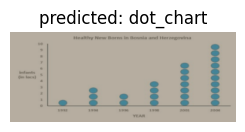

In [110]:
visualize_model(model,6)

# Inference on one image

In [130]:
img = 'drive/MyDrive/Kaggle/benetech-making-graphs-accessible/train/images/line_chart/0acd50bd749a.jpg'

In [131]:
loader = v2.Compose([
    v2.ToImage(),
    v2.Resize(image_size,antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])
model.eval()

def image_loader(image_name):
    """load image, returns cuda tensor"""
    image = Image.open(image_name)
    image = loader(image).float()
    image = image.unsqueeze(0)  #this is for VGG, may not be needed for ResNet
    return image.to(device)  #assumes that you're using GPU

image = image_loader(img)

In [132]:
with torch.no_grad():
  img_predictions = model(image)

In [133]:
pred_label = class_map[np.argmax(np.round(img_predictions.cpu()[0].numpy(),2))]
print(" Predicted label is :: "+ pred_label)

 Predicted label is :: line_chart


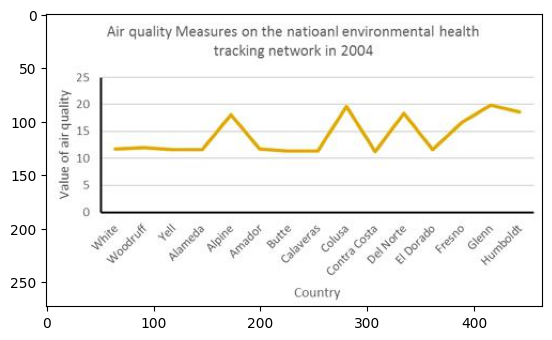

In [134]:
plt.imshow(Image.open(img))